In [37]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [38]:
from fem import (
    # Core
    Material,
    # Sections
    Membrane,
    # Gmsh tools
    GMSHtools,
    # Model
    FEMModel,
    # Elements
    CST, LST, Quad4, Quad9,
    # Units
    kgf, tf, kN, MPa, GPa, kg, g, cm, m, mm,
    # Parameters
    globalParameters,
)


import os
import numpy as np
import matplotlib.pyplot as plt
import gmsh
np.set_printoptions(suppress=True, precision=6, linewidth=400)

In [39]:
globalParameters['nDoF'] = 2
globalParameters['nDIM'] = 2

In [40]:
# General model parameters

output_path = os.getcwd()
mesh_name = 'Cantiliverbeam'
output_file = os.path.join(output_path, mesh_name + '.msh')

if not os.path.exists(output_path):
    os.makedirs(output_path)

In [41]:
# gmsh.initialize()
# gmsh.model.add(mesh_name)

# # Points
# p1 = gmsh.model.geo.addPoint(0,    0,    0)
# p2 = gmsh.model.geo.addPoint(0,    1600, 0)
# p3 = gmsh.model.geo.addPoint(600,  1600, 0)
# p4 = gmsh.model.geo.addPoint(605,  1400, 0)
# p5 = gmsh.model.geo.addPoint(610,  1600, 0)
# p6 = gmsh.model.geo.addPoint(2800, 1600, 0)
# p7 = gmsh.model.geo.addPoint(2800, 600,  0)
# p8 = gmsh.model.geo.addPoint(1,    1600, 0)

# # Lines
# l1 = gmsh.model.geo.addLine(p1, p7)
# l2 = gmsh.model.geo.addLine(p7, p6)
# l3 = gmsh.model.geo.addLine(p6, p5)
# l4 = gmsh.model.geo.addLine(p5, p4)
# l5 = gmsh.model.geo.addLine(p4, p3)
# l6 = gmsh.model.geo.addLine(p3, p8)
# l7 = gmsh.model.geo.addLine(p8, p2)
# l8 = gmsh.model.geo.addLine(p2, p1)

# # Surface
# c1 = gmsh.model.geo.addCurveLoop([l8, l1, l2, l3, l4, l5, l6, l7])
# s1 = gmsh.model.geo.addPlaneSurface([c1])

# gmsh.model.geo.synchronize()

# # Transfinite curves
# gmsh.model.mesh.setTransfiniteCurve(l8, 16)
# gmsh.model.mesh.setTransfiniteCurve(l1, 25)
# gmsh.model.mesh.setTransfiniteCurve(l2, 10)
# gmsh.model.mesh.setTransfiniteCurve(l3, 20)
# gmsh.model.mesh.setTransfiniteCurve(l6,  6)
# gmsh.model.mesh.setTransfiniteCurve(l5,  4)
# gmsh.model.mesh.setTransfiniteCurve(l4,  4)
# gmsh.model.mesh.setTransfiniteCurve(l7,  2)

# # Physical groups
# gmsh.model.addPhysicalGroup(1, [l8],      9)
# gmsh.model.setPhysicalName( 1,  9, 'Empotrado')
# gmsh.model.addPhysicalGroup(1, [l6, l3], 10)
# gmsh.model.setPhysicalName( 1, 10, 'Carga')
# gmsh.model.addPhysicalGroup(2, [s1],     11)
# gmsh.model.setPhysicalName( 2, 11, 'Con')

# gmsh.model.geo.synchronize()


# def all_quads():
#     gmsh.model.geo.synchronize()
#     gmsh.option.setNumber("Mesh.RecombineAll", 1)
#     gmsh.option.setNumber("Mesh.Algorithm", 8)
#     gmsh.option.setNumber("Mesh.RecombinationAlgorithm", 2)
#     gmsh.option.setNumber("Mesh.Smoothing", 100)
#     gmsh.option.setNumber("Mesh.ElementOrder", 1)

# # all_quads()


In [42]:
gmsh.initialize()
gmsh.model.add(mesh_name)

lc = 100

# Points
p1 = gmsh.model.geo.addPoint(0,    0,    0, lc)
p2 = gmsh.model.geo.addPoint(0,    1600, 0, lc)
p3 = gmsh.model.geo.addPoint(600,  1600, 0, lc)
p4 = gmsh.model.geo.addPoint(605,  1400, 0, lc)
p5 = gmsh.model.geo.addPoint(610,  1600, 0, lc)
p6 = gmsh.model.geo.addPoint(2800, 1600, 0, lc)
p7 = gmsh.model.geo.addPoint(2800, 600,  0, lc)
p8 = gmsh.model.geo.addPoint(1,    1600, 0, lc)

# Lines
l1 = gmsh.model.geo.addLine(p1, p7)
l2 = gmsh.model.geo.addLine(p7, p6)
l3 = gmsh.model.geo.addLine(p6, p5)
l4 = gmsh.model.geo.addLine(p5, p4)
l5 = gmsh.model.geo.addLine(p4, p3)
l6 = gmsh.model.geo.addLine(p3, p8)
l7 = gmsh.model.geo.addLine(p8, p2)
l8 = gmsh.model.geo.addLine(p2, p1)

# Surface
c1 = gmsh.model.geo.addCurveLoop([l8, l1, l2, l3, l4, l5, l6, l7])
s1 = gmsh.model.geo.addPlaneSurface([c1])

gmsh.model.geo.synchronize()

# Physical groups
gmsh.model.addPhysicalGroup(1, [l8],      9)
gmsh.model.setPhysicalName( 1,  9, 'Empotrado')
gmsh.model.addPhysicalGroup(1, [l6, l3], 10)
gmsh.model.setPhysicalName( 1, 10, 'Carga')
gmsh.model.addPhysicalGroup(2, [s1],     11)
gmsh.model.setPhysicalName( 2, 11, 'Con')

gmsh.model.geo.synchronize()

def all_quads():
    gmsh.model.geo.synchronize()
    gmsh.option.setNumber("Mesh.RecombineAll", 1)
    gmsh.option.setNumber("Mesh.Algorithm", 8)
    gmsh.option.setNumber("Mesh.RecombinationAlgorithm", 2)
    gmsh.option.setNumber("Mesh.Smoothing", 100)
    gmsh.option.setNumber("Mesh.ElementOrder", 1)

# all_quads()
gmsh.option.setNumber("Mesh.ElementOrder", 2)

In [43]:
# Generate the mesh
gmsh.model.mesh.generate()
# Save mesh to disk
gmsh.write(output_file)
# Open GMSH GUI
gmsh.fltk.run()
# Write mesh file again (redundant)
v = gmsh.write(output_file)
# Close GMSH instance
gmsh.finalize()

In [44]:
fcp = 40*MPa
fct = 0.35*np.sqrt(fcp/MPa)*MPa
thickness = 1*m
rho = 2500 * kg/m**3

qload = (0.50*kN/mm)/(1*m)
# qload = (0.5*tf/m)/(1*m)

#Constants
E_conc = 4700*np.sqrt(fcp/MPa)*MPa
nu_conc = 0.17

In [45]:
# Definimos el material
Concrete=Material(name='Concrete',
             E=E_conc,
             nu=nu_conc,
             rho=rho*0)

# Definimos una seccion de la membrana
Cantiliverbeam=Membrane(name='Cantiliverbeam',
                thickness=thickness,
                material=Concrete)

section_dictionary={11:Cantiliverbeam,
                        }


restrain_dictionary={9:['r', 'r']}



load_dictionary = {
    10:   {'value': qload, 'direction': '-y'},   # line load  [N/mm]
    # 258: {'value': -30,   'direction': 'y'},     # point load [N]
}


In [46]:
# read mesh 
mesh = GMSHtools(output_file)

  MESH SUMMARY

  === NODES ===  (1861 total — showing first 3)
     Tag              x              y              z
--------------------------------------------------------------------------------
       1         0.0000         0.0000         0.0000
       2         0.0000      1600.0000         0.0000
       3       600.0000      1600.0000         0.0000
--------------------------------------------------------------------------------

  === PHYSICAL GROUPS ===  (3 total)
      ID    Dim   Name
--------------------------------------------------------------------------------
       9      1   'Empotrado'
      10      1   'Carga'
      11      2   'Con'
--------------------------------------------------------------------------------

  === ELEMENTS ===  (3 groups)
      ID    Dim     Type   Nodes/el   N elements   Name
--------------------------------------------------------------------------------
       9      1        8          3           16   'Empotrado'
      10      1        

In [47]:
# Map number of nodes per element to element class
element_map = {
    3: CST,         # 3-node triangles
    4: Quad4,       # 4-node quadrilaterals
    6: LST,         # 6-node triangles
    9: Quad9,       # 9-node quadrilaterals
}

# Build FEM model — applies BCs, builds elements, assembles load vector
model = FEMModel(
    mesh                = mesh,
    section_dictionary  = section_dictionary,
    restrain_dictionary = restrain_dictionary,
    load_dictionary     = load_dictionary,
    element_class_map   = element_map,
    analysis_type       = 'planeStress',
    consistent_loads    = True,
    sampling_points     = 3,

    verbose=True,
)


  FEM MODEL SUMMARY
--------------------------------------------------------------------------------
  Analysis type    : planeStress
  Nodes            : 1861
  system_nDof      : 3722
  Elements         : 886
  Steps FEM        : 0
  Steps OpenSees   : 0

  --- Sections ---
  [11] Con                   t=1000  E=29725.41  nu=0.170

  --- Restrained nodes ---
  Node      1  [0. 0.]                         ['r', 'r']
  Node      2  [   0. 1600.]                   ['r', 'r']
  Node    146  [   0. 1500.]                   ['r', 'r']
  Node    147  [   0. 1400.]                   ['r', 'r']
  Node    148  [   0. 1300.]                   ['r', 'r']
  Node    149  [   0. 1200.]                   ['r', 'r']
  Node    150  [   0. 1100.]                   ['r', 'r']
  Node    151  [   0. 1000.]                   ['r', 'r']
  Node    152  [  0. 900.]                     ['r', 'r']
  Node    153  [  0. 800.]                     ['r', 'r']
  Node    154  [  0. 700.]                     ['r', 'r'

In [48]:
# Mesh diagnostics
model.check_mesh()


  MESH DIAGNOSTICS
--------------------------------------------------------------------------------
  Nodes            : 1861
  system_nDof      : 3722
  Elements         : 886
  Physical groups  : 3

  --- Orphan nodes ---
  OK — no orphan nodes

  --- Physical groups ---
      ID   Dim  Name                    Elements     Nodes  Section
  ------  ----  --------------------  ----------  --------  ----------
       9     1  Empotrado                     16        33  N/A
      10     1  Carga                         28        58  N/A
      11     2  Con                          886      1861  OK

  --- Restrained nodes ---
     Tag             x             y  Condition
  ------  ------------  ------------  ------------
       1        0.0000        0.0000  ['r', 'r']
       2        0.0000     1600.0000  ['r', 'r']
     146        0.0000     1500.0000  ['r', 'r']
     147        0.0000     1400.0000  ['r', 'r']
     148        0.0000     1300.0000  ['r', 'r']
     149        0.0000 

In [49]:
# Solve — single step
model.solve_static(
    n_steps=1, 
    load_factor=1.0,
    verbose = True,
)


  SOLVE SUMMARY
--------------------------------------------------------------------------------
  Steps solved     : 1
  Last load factor : 1.0000
  Max |ux|         : 0.226227
  Max |uy|         : 0.714896
  Max Von Mises    : 6.7543

  --- Equilibrium ---
  Applied  Fx: +0.0000   Reaction Rx: +0.0000   Balance: 6.0449e-08
  Applied  Fy: -1394500.0000   Reaction Ry: +1394500.0000   Balance: -6.7521e-09
--------------------------------------------------------------------------------



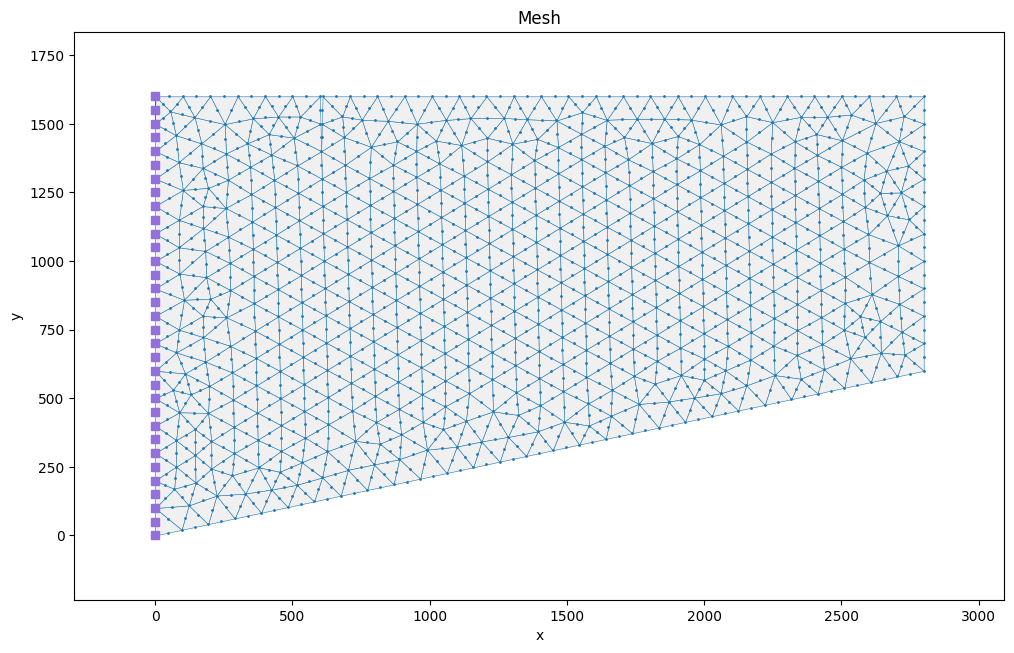

In [50]:
# Plot mesh
model.plot(
    step                = -1,
    show_node_labels    = False,
    show_element_labels = False,
    show_supports       = True,
    show_element_edges  = True,
    show_node_points    = True,
    figsize             = (12, 8),
)

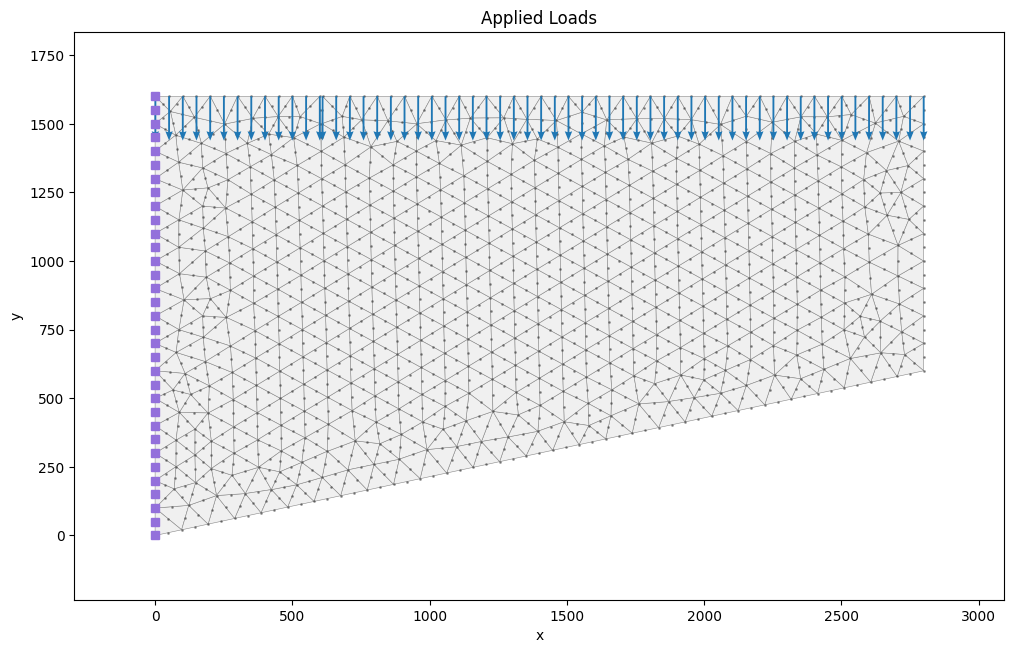

In [51]:
# Plot loads
model.plot_loads(
    show_element_edges = True,
    show_node_points   = True,
    show_supports      = True,
    figsize            = (12, 8),
)

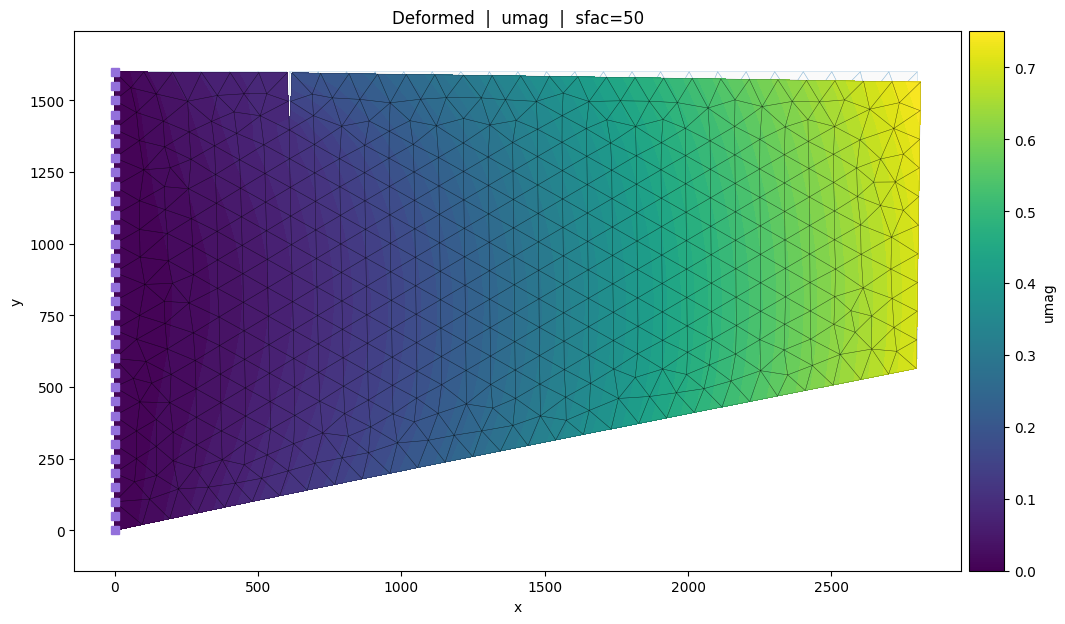

In [52]:
# Plot deformed
model.plot_deformed(
    sfac                = 50,
    step                = -1,
    component           = 'umag',   # 'ux', 'uy', 'umag'
    cmap                = 'viridis',
    show_element_edges  = True,
    show_supports       = True,
    figsize             = (12, 8),
)

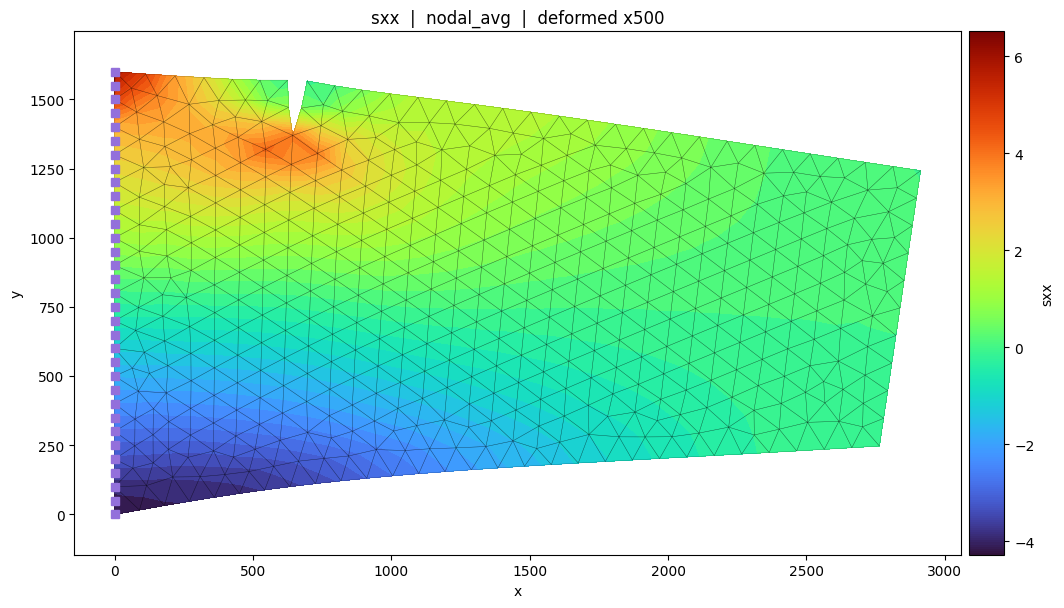

In [56]:
# Plot field
model.plot_field(
    component           = 'sxx',        # 'sxx','syy','sxy','vmis','s1','s2','exx','eyy','exy'
    source              = 'fem',
    step                = -1,
    result_type         = 'nodal_avg',  # 'nodal_avg' or 'element'
    deformed            = True,
    sfac                = 500,
    cmap                = 'turbo',
    show_element_edges  = True,
    show_supports       = True,
    figsize             = (12, 8),
)

In [54]:
# Send to gmsh — static
model.plot2gmsh(
    step            = -1,
    source         = 'fem',
    disp_factor     = 50,
    show_disp       = True,
    show_loads      = True,
    show_reactions  = True,
    show_stress     = True,
    show_strain     = True,
    show_vm         = True,
    show_averaged   = True,

)